# 7th attempt - U-NET (10×10)

In [1]:
# Imports
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, precision_score, recall_score

import functions
import importlib
importlib.reload(functions)
from functions import load_reverse_df

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow version: 2.19.0
GPU available: False


In [2]:
# Configuration
SIZE = 10
AMOUNT_BOARDS = 10000
gen = 3
PAD = 2  # wrap padding for toroidal topology

In [3]:
# Load data — full board prediction (input=state T, target=state T-1)
reverse_df = load_reverse_df(SIZE, AMOUNT_BOARDS, gen)
n_pixels = SIZE * SIZE

feat_cols = [f'Col_{i}' for i in range(n_pixels)]
tgt_cols  = [f'Col_{n_pixels + i}' for i in range(n_pixels)]

X_all = reverse_df[feat_cols].to_numpy().reshape(-1, SIZE, SIZE, 1).astype('float32')
y_all = reverse_df[tgt_cols].to_numpy().reshape(-1, SIZE, SIZE, 1).astype('float32')

# Train / val / test split
X_tv, X_test, y_tv, y_test = train_test_split(X_all, y_all, test_size=0.1, random_state=365)
X_train, X_val, y_train, y_val = train_test_split(X_tv, y_tv, test_size=0.1, random_state=365)

print(f"Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}")
print(f"Input shape:  {X_train.shape}")
print(f"Target shape: {y_train.shape}")
print(f"Alive fraction (train target): {np.mean(y_train):.3f}")

KeyboardInterrupt: 

In [ ]:
# D4 data augmentation (8× more training data)
# GoL rules are rotationally symmetric → all 8 D4 transforms are valid
def augment_d4(X, y):
    Xs, ys = [X], [y]
    for k in range(1, 4):  # 90°, 180°, 270°
        Xs.append(np.rot90(X, k, axes=(1, 2)))
        ys.append(np.rot90(y, k, axes=(1, 2)))
    X_flip = X[:, :, ::-1, :]
    y_flip = y[:, :, ::-1, :]
    Xs.append(X_flip)
    ys.append(y_flip)
    for k in range(1, 4):
        Xs.append(np.rot90(X_flip, k, axes=(1, 2)))
        ys.append(np.rot90(y_flip, k, axes=(1, 2)))
    return np.concatenate(Xs), np.concatenate(ys)

X_train_aug, y_train_aug = augment_d4(X_train, y_train)

# Shuffle
rng = np.random.default_rng(42)
idx = rng.permutation(len(X_train_aug))
X_train_aug, y_train_aug = X_train_aug[idx], y_train_aug[idx]

print(f"Original train: {X_train.shape[0]}")
print(f"Augmented train: {X_train_aug.shape[0]} (8× D4)")

Original train: 327960
Augmented train: 2623680 (8× D4)


In [ ]:
# ============================================================
# Build U-NET Model (CPU-friendly version)
# ============================================================
# U-NET architecture:
#   - Encoder: conv blocks with MaxPool (captures context at multiple scales)
#   - Decoder: UpSampling + skip connections from encoder (recovers spatial detail)
#   - Wrap padding: handles toroidal GoL topology
#   - Attention gates: focus skip connections on relevant features
#
# Using smaller filters for CPU training speed
# ============================================================

tf.keras.backend.clear_session()

def wrap_pad(x, pad=2):
    """Toroidal wrap-padding."""
    top = x[:, -pad:, :, :]
    bot = x[:, :pad, :, :]
    x_p = tf.concat([top, x, bot], axis=1)
    left = x_p[:, :, -pad:, :]
    right = x_p[:, :, :pad, :]
    return tf.concat([left, x_p, right], axis=2)

def conv_block(x, filters, dropout_rate=0.1):
    """Two conv layers with BatchNorm, ReLU, residual shortcut."""
    shortcut = x
    if x.shape[-1] != filters:
        shortcut = tf.keras.layers.Conv2D(filters, 1, padding='same')(shortcut)
        shortcut = tf.keras.layers.BatchNormalization()(shortcut)
    x = tf.keras.layers.Conv2D(filters, 3, padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.SpatialDropout2D(dropout_rate)(x)
    x = tf.keras.layers.Conv2D(filters, 3, padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Add()([x, shortcut])
    x = tf.keras.layers.Activation('relu')(x)
    return x

def attention_gate(skip, gating, filters):
    """Additive attention gate for skip connections."""
    W_skip = tf.keras.layers.Conv2D(filters, 1, padding='same', use_bias=False)(skip)
    W_gate = tf.keras.layers.Conv2D(filters, 1, padding='same', use_bias=False)(gating)
    psi = tf.keras.layers.Activation('relu')(W_skip + W_gate)
    psi = tf.keras.layers.Conv2D(1, 1, padding='same', activation='sigmoid')(psi)
    return tf.keras.layers.Multiply()([skip, psi])

# --- Build Attention Residual U-NET ---
BASE_FILTERS = 16   # Small for CPU speed
DEPTH = 2           # 2 encoder/decoder levels

inp = tf.keras.Input(shape=(SIZE, SIZE, 1), name='input_board_T')

# Wrap-pad input for toroidal topology
x = tf.keras.layers.Lambda(wrap_pad, arguments={'pad': PAD}, name='wrap_pad')(inp)

# === ENCODER ===
skips = []
filters = BASE_FILTERS
for i in range(DEPTH):
    x = conv_block(x, filters)
    skips.append(x)
    x = tf.keras.layers.MaxPooling2D(2, padding='same')(x)
    filters *= 2

# === BOTTLENECK ===
x = conv_block(x, filters)

# === DECODER ===
for i in reversed(range(DEPTH)):
    filters //= 2
    x = tf.keras.layers.UpSampling2D(2)(x)
    # Crop to match skip shape
    skip = skips[i]
    target_h, target_w = skip.shape[1], skip.shape[2]
    x = tf.keras.layers.Lambda(
        lambda t, th=target_h, tw=target_w: t[:, :th, :tw, :]
    )(x)
    # Attention-gated skip connection
    skip_att = attention_gate(skip, x, filters)
    x = tf.keras.layers.Concatenate()([x, skip_att])
    x = conv_block(x, filters)

# === OUTPUT: 1x1 conv → sigmoid → crop back to 10×10 ===
x = tf.keras.layers.Conv2D(1, 1, activation='sigmoid', name='pred_raw')(x)
x = tf.keras.layers.Cropping2D(cropping=((PAD, PAD), (PAD, PAD)), name='output_T_minus_1')(x)

model_unet = tf.keras.Model(inp, x, name='AttentionResUNet')
model_unet.summary()
print(f"\nTotal parameters: {model_unet.count_params():,}")

Model: "AttentionResUNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_board_T       │ (None, 10, 10, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ wrap_pad (Lambda)   │ (None, 14, 14, 1) │          0 │ input_board_T[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 14, 14,    │        160 │ wrap_pad[0][0]    │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 14, 14,    │         64 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 14, 14,    │          0 │ batch_normalizat… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout2d   │ (None, 14, 14,    │          0 │ activation[0][0]  │
│ (SpatialDropout2D)  │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 14, 14,    │      2,320 │ spatial_dropout2… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 14, 14,    │         32 │ wrap_pad[0][0]    │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 14, 14,    │         64 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 14, 14,    │         64 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 14, 14,    │          0 │ batch_normalizat… │
│                     │ 16)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 14, 14,    │          0 │ add[0][0]         │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 7, 7, 16)  │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 7, 7, 32)  │      4,640 │ max_pooling2d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 7, 7, 32)  │        128 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 7, 7, 32)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout2d_1 │ (None, 7, 7, 32)  │          0 │ activation_2[0][… │
│ (SpatialDropout2D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 130,371 (509.26 KB)

 Trainable params: 129,411 (505.51 KB)

 Non-trainable params: 960 (3.75 KB)


Total parameters: 130,371


In [ ]:
# Compile and Train U-NET
# Using subsample for CPU speed, augmented data available if GPU later
TRAIN_LIMIT = 200000  # subsample for CPU training speed
X_tr = X_train[:TRAIN_LIMIT]
y_tr = y_train[:TRAIN_LIMIT]
print(f"Training on {len(X_tr)} samples (of {len(X_train)} available)")

model_unet.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=5e-4),
    loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=0.03),
    metrics=['accuracy']
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=8,
        restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3,
        min_lr=1e-6, verbose=1),
]

history = model_unet.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=80,
    batch_size=512,
    callbacks=callbacks,
    verbose=2
)

Training on 50000 samples (of 327960 available)
Epoch 1/80
98/98 - 66s - 668ms/step - accuracy: 0.8042 - loss: 0.4283 - val_accuracy: 0.7952 - val_loss: 0.4752 - learning_rate: 0.0010
Epoch 2/80
98/98 - 72s - 734ms/step - accuracy: 0.8454 - loss: 0.3666 - val_accuracy: 0.7953 - val_loss: 0.4650 - learning_rate: 0.0010
Epoch 3/80
98/98 - 46s - 470ms/step - accuracy: 0.8577 - loss: 0.3493 - val_accuracy: 0.8119 - val_loss: 0.4029 - learning_rate: 0.0010
Epoch 4/80
98/98 - 81s - 822ms/step - accuracy: 0.8632 - loss: 0.3407 - val_accuracy: 0.8507 - val_loss: 0.3565 - learning_rate: 0.0010
Epoch 5/80
98/98 - 82s - 832ms/step - accuracy: 0.8667 - loss: 0.3352 - val_accuracy: 0.8657 - val_loss: 0.3370 - learning_rate: 0.0010
Epoch 6/80
98/98 - 45s - 462ms/step - accuracy: 0.8690 - loss: 0.3314 - val_accuracy: 0.8713 - val_loss: 0.3284 - learning_rate: 0.0010
Epoch 7/80
98/98 - 56s - 567ms/step - accuracy: 0.8707 - loss: 0.3285 - val_accuracy: 0.8738 - val_loss: 0.3244 - learning_rate: 0.0010


In [ ]:
# ============================================================
# Evaluate U-NET
# ============================================================
# Forward consistency: step predicted T-1 forward and check if it recreates T
def gol_step_np(boards):
    """Apply one GoL step to a batch of boards (toroidal)."""
    if boards.ndim == 4:
        boards = boards[..., 0]
    b = boards.astype(np.float32)
    padded = np.pad(b, ((0,0),(1,1),(1,1)), mode='wrap')
    n, h, w = b.shape
    neigh = np.zeros_like(b)
    for di in (-1, 0, 1):
        for dj in (-1, 0, 1):
            if di == 0 and dj == 0:
                continue
            neigh += padded[:, 1+di:h+1+di, 1+dj:w+1+dj]
    alive = b.astype(bool)
    survive = alive & ((neigh == 2) | (neigh == 3))
    birth = (~alive) & (neigh == 3)
    return (survive | birth).astype(np.float32)[..., np.newaxis]

# --- Test accuracy ---
test_loss, test_acc = model_unet.evaluate(X_test, y_test, verbose=0)
print(f"Test pixel accuracy: {test_acc:.4f}")

# --- Forward consistency ---
y_pred = model_unet.predict(X_test, verbose=0)
pred_binary = (y_pred > 0.5).astype(np.float32)
stepped = gol_step_np(pred_binary)
fc_score = np.mean(stepped == (X_test > 0.5).astype(np.float32))
print(f"Forward consistency: {fc_score:.4f}")

# --- Per-class accuracy ---
all_pred = (y_pred > 0.5).astype(int)
all_true = y_test.astype(int)
alive_mask = all_true.flatten() == 1
dead_mask = all_true.flatten() == 0
print(f"ALIVE cell accuracy: {np.mean(all_pred.flatten()[alive_mask] == 1):.4f}")
print(f"DEAD cell accuracy:  {np.mean(all_pred.flatten()[dead_mask] == 0):.4f}")

# --- Pixel-0 metrics ---
p0_pred = all_pred[:, 0, 0, 0]
p0_true = all_true[:, 0, 0, 0]
p0_f1 = f1_score(p0_true, p0_pred)
print(f"Pixel-0 acc={np.mean(p0_pred==p0_true):.4f}  F1={p0_f1:.4f}")

# --- Training curves ---
best_train = max(history.history['accuracy'])
best_val = max(history.history['val_accuracy'])
print(f"\nBest train accuracy: {best_train:.4f}")
print(f"Best val accuracy:   {best_val:.4f}")
print(f"Overfitting gap:     {best_train - best_val:.4f}")

if best_val >= 0.90:
    print("\n>>> TARGET 0.90 REACHED! <<<")
    model_unet.save("models/UNET_10_best.keras")
else:
    print(f"\nGap to 0.90 target: {0.90 - best_val:.4f}")

Test pixel accuracy: 0.8805
ALIVE cell accuracy: 0.6379
DEAD cell accuracy:  0.9432
  F1=0.6778

Best train accuracy: 0.8890
Best val accuracy:   0.8813
Overfitting gap:     0.0077

Gap to 0.90 target: 0.0187


In [ ]:
# ============================================================
# Threshold tuning to improve ALIVE cell accuracy
# ============================================================
# Default threshold=0.5 is biased toward DEAD (majority class ~80%).
# Lowering the threshold → model predicts "alive" more often → better alive recall.

y_pred_val = model_unet.predict(X_val, verbose=0)
val_true = y_val.astype(int)

print(f"{'Thresh':>7} | {'Overall':>8} | {'ALIVE':>8} | {'DEAD':>8} | {'FC':>8}")
print("-" * 55)

best_thresh = 0.5
best_alive_acc = 0
best_overall = 0

for thresh in [0.70, 0.60, 0.50, 0.45, 0.40, 0.35, 0.30, 0.25, 0.20]:
    pred = (y_pred_val > thresh).astype(int)
    overall = np.mean(pred == val_true)
    alive_mask_v = val_true.flatten() == 1
    dead_mask_v = val_true.flatten() == 0
    alive_acc = np.mean(pred.flatten()[alive_mask_v] == 1)
    dead_acc = np.mean(pred.flatten()[dead_mask_v] == 0)
    
    # Forward consistency at this threshold
    pred_bin = (y_pred_val > thresh).astype(np.float32)
    stepped = gol_step_np(pred_bin)
    fc = np.mean(stepped == (X_val > 0.5).astype(np.float32))
    
    print(f"  {thresh:.2f}  | {overall:.4f}  | {alive_acc:.4f}  | {dead_acc:.4f}  | {fc:.4f}")
    
    # Pick best threshold by overall accuracy
    if overall > best_overall:
        best_overall = overall
        best_thresh = thresh
        best_alive_acc = alive_acc

print(f"\nBest threshold: {best_thresh:.2f} (overall={best_overall:.4f}, alive={best_alive_acc:.4f}")

 Thresh |  Overall |    ALIVE |     DEAD |       FC
-------------------------------------------------------
  0.70  | 0.8685  | 0.4396  | 0.9790  | 0.8103
  0.60  | 0.8783  | 0.5470  | 0.9636  | 0.8509
  0.50  | 0.8813  | 0.6388  | 0.9437  | 0.8875
  0.45  | 0.8801  | 0.6804  | 0.9316  | 0.8933
  0.40  | 0.8774  | 0.7197  | 0.9179  | 0.8868
  0.35  | 0.8725  | 0.7567  | 0.9023  | 0.8674
  0.30  | 0.8649  | 0.7914  | 0.8839  | 0.8376
  0.25  | 0.8542  | 0.8250  | 0.8617  | 0.8011
  0.20  | 0.8387  | 0.8574  | 0.8339  | 0.7623

Best threshold: 0.50 (overall=0.8813, alive=0.6388


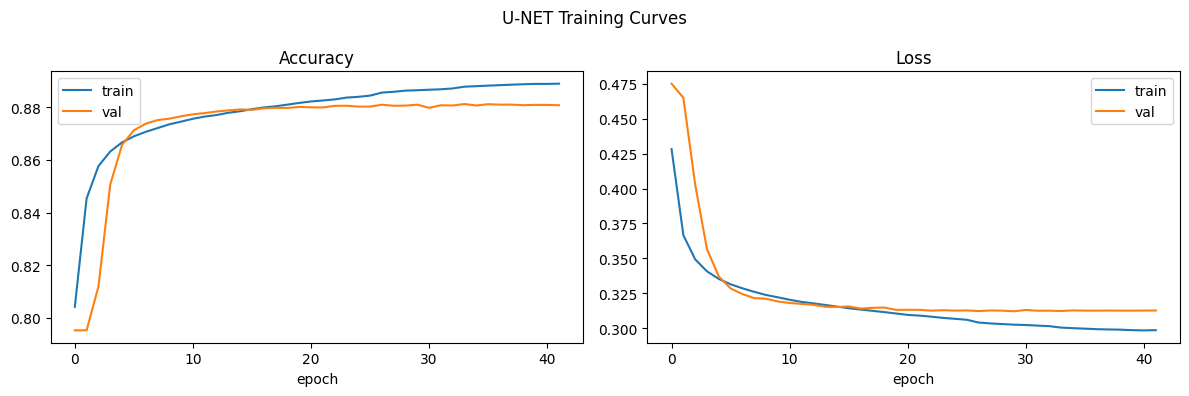

In [ ]:
# Training history plot
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['accuracy'], label='train')
ax1.plot(history.history['val_accuracy'], label='val')
ax1.set_title('Accuracy')
ax1.set_xlabel('epoch')
ax1.legend()

ax2.plot(history.history['loss'], label='train')
ax2.plot(history.history['val_loss'], label='val')
ax2.set_title('Loss')
ax2.set_xlabel('epoch')
ax2.legend()

plt.suptitle('U-NET Training Curves')
plt.tight_layout()
plt.show()